## Inicialización del entorno

### Configurar y montar Google Drive

In [2]:
import sys
import os

# Directorio actual donde se está ejecutando el notebook
ruta_base = os.getcwd()

ruta_padre = os.path.abspath(os.path.join(ruta_base, '..'))

if ruta_padre not in sys.path:
    sys.path.append(ruta_padre)

print(f"Directorio de trabajo: {ruta_base}")
print(f"Directorio padre (añadido al path): {ruta_padre}")

Directorio de trabajo: c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning
Directorio padre (añadido al path): c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1


### Importación de librerías

In [ ]:
#!pip install -U pymgrid
#!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 60.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.4 MB/s eta 0:00:00
  Created wheel for pymgrid: filename=pymgrid-1.2.2-py3-none-any.whl size=3492844 sha256=237c6d04b7f82e5aa6cfd53d72ef70303b1a3743dc1920f84d8e14c326b2004a
  Stored in directory: /root/.cache/pip/wheels/22/74/ee/35d2b7ad23381dc521b2c8670c6e30be0b2e9fe80a1fe03160
Successfully built pymgrid
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from pymgrid import Microgrid
from pymgrid.modules import GridModule, BatteryModule, LoadModule, RenewableModule
import random
from collections import defaultdict

from custom_env_tabular_normalized import CustomEnvTabular

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import os
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ModuleNotFoundError: No module named 'seaborn'

### Carga y preparación de datos

In [4]:
# PRECIOS DE LA RED (Península 2025)
ruta_precios = os.path.join(ruta_padre, 'data', 'external', 'precio2025-peninsula.csv')
df_precios = pd.read_csv(ruta_precios, sep=';')
df_precios['datetime'] = pd.to_datetime(df_precios['datetime'], utc=True)
df_precios = df_precios.sort_values('datetime').reset_index(drop=True)
# Convertir de €/MWh a €/kWh
precios_kwh = df_precios['value'].values / 1000.0

# DEMANDA (LOAD) Y GENERACIÓN SOLAR (PV)
ruta_load = os.path.join(ruta_padre, 'data', 'raw', 'load', 'RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv')
ruta_pv = os.path.join(ruta_padre, 'data', 'processed', 'pv_generacion_corregida_kw.csv')

df_load = pd.read_csv(ruta_load)
df_pv = pd.read_csv(ruta_pv)

load_series = df_load.iloc[:, -1].values
pv_series = df_pv.iloc[:, -1].values

# Asegurarnos de que todas las series tienen la misma longitud
min_len = min(len(precios_kwh), len(load_series), len(pv_series), 8760)
precios_kwh = precios_kwh[:min_len]
load_series = load_series[:min_len]
pv_series = pv_series[:min_len]

print(f"Datos cargados correctamente. Longitud de las series: {min_len} horas.")

Datos cargados correctamente. Longitud de las series: 8760 horas.


### Creación de los módulos de pymgrid

In [5]:
# RED ELÉCTRICA (GridModule)
# En las versiones recientes de pymgrid, los datos de la red se pasan como un DataFrame
grid_ts = pd.DataFrame({
    'import_price': precios_kwh,
    'export_price': precios_kwh * 0.5,
    'co2_per_kwh': 0.0                 # Rellenamos con 0, pero pymgrid necesita esta columna
})

grid = GridModule(
    max_import=10000.0,
    max_export=10000.0,
    time_series=grid_ts
)

# BATERÍA (BatteryModule)
battery = BatteryModule(
    min_capacity=10.0,
    max_capacity=200.0,
    max_charge=50.0,
    max_discharge=50.0,
    efficiency=0.9,
    init_soc=0.5
)

# DEMANDA Y PLACAS SOLARES
# Les pasamos directamente los arrays con los kW de cada hora
load = LoadModule(time_series=load_series)
pv = RenewableModule(time_series=pv_series)

### Ensamblaje de la microrred y el entorno gymnasium

In [6]:
# Creamos la lista de tuplas con el nombre ('string') y el objeto de cada módulo
modules = [
    ('grid', grid),
    ('battery', battery),
    ('load', load),
    ('pv', pv)
]

# Construimos la microrred
microrred = Microgrid(modules)

env = CustomEnvTabular(
    pymgrid_network=microrred,
    horizon=min_len,
    reward_scale_C=787.05,
    low_soc_penalty=0.3,
    low_soc_threshold=0.05
)

### Prueba de funcionamiento

In [7]:
obs, info = env.reset()
print("¡Entorno inicializado con éxito, sin errores!")
print(f"Estado Inicial Discretizado [Carga_Neta, Batería_SoC, Precio, Hora]: {obs}")
print(f"Precio extraído para la primera hora: {info['current_import_price']:.4f} €/kWh")

¡Entorno inicializado con éxito, sin errores!
Estado Inicial Discretizado [Carga_Neta, Batería_SoC, Precio, Hora]: [2 5 3 0]
Precio extraído para la primera hora: 0.1832 €/kWh


# Funciones auxiliares

In [8]:
# 1. FUNCIÓN DE MUESTREO DE HIPERPARÁMETROS
def sample_q_params(trial):
    """Muestrea los hiperparámetros para Q-Learning Tabular."""
    return {
        "alpha": trial.suggest_float("alpha", 0.01, 0.3, log=True),
        "gamma": trial.suggest_float("gamma", 0.90, 0.999),
        "epsilon_decay_step": trial.suggest_float("epsilon_decay_step", 0.99990, 0.99999),
        "epsilon_min": 0.05
    }

In [9]:
# 2. FUNCIÓN DE EVALUACIÓN PURA (Sin exploración)
def evaluate_agent(env, Q, eval_episodes=1):
    """Evalúa la Q-Table actual (pura explotación) y devuelve el coste medio."""
    total_eval_cost = 0
    for _ in range(eval_episodes):
        obs, info = env.reset()
        state = tuple(obs)
        done = False
        ep_cost = 0

        while not done:
            # 1. Elegir la acción (ya sea por Q-Table o al azar si es desconocido)
            if state in Q:
                q_values = Q[state]
                # Encuentra los valores máximos y elige uno al azar entre los empatados
                best_actions = np.where(q_values == np.max(q_values))[0]
                action = np.random.choice(best_actions)
            else:
                action = env.action_space.sample()

            # 2. Ejecutar la acción en el entorno
            next_obs, reward, terminated, truncated, info = env.step(action)
            state = tuple(next_obs)
            done = terminated or truncated
            ep_cost += info.get('cost', 0)

        total_eval_cost += ep_cost

    return total_eval_cost / eval_episodes

In [6]:
GLOBAL_BEST_DIR = os.path.join(ruta_base, "Q-learning")
os.makedirs(GLOBAL_BEST_DIR, exist_ok=True)
GLOBAL_BEST_PATH = os.path.join(GLOBAL_BEST_DIR, "best_q_table.pkl")
db_file_path = os.path.join(GLOBAL_BEST_DIR, "optuna_microgrid.db")
DB_PATH = f"sqlite:///{db_file_path.replace(os.sep, '/')}"

In [11]:
# Lógica para mantener el récord absoluto entre versiones
global_best_cost = float('inf')

# 1. Heredar el récord de v1 y v2
for old_study in ["microgrid_qlearning_v1", "microgrid_qlearning_v2"]:
    try:
        temp_study = optuna.load_study(study_name=old_study, storage=DB_PATH)
        if temp_study.best_value < global_best_cost:
            global_best_cost = temp_study.best_value
    except Exception:
        pass

print(f"Récord histórico a batir (v1/v2): {global_best_cost:.2f} €")

# 2. Cargar el récord de v3 (por si reanudas la celda)
try:
    study_v3 = optuna.load_study(study_name="microgrid_qlearning_v3_normalized", storage=DB_PATH)
    if study_v3.best_value < global_best_cost:
        global_best_cost = study_v3.best_value
    print(f"Reanudando estudio v3. Mejor coste actual: {global_best_cost:.2f} €")
except Exception:
    print("Iniciando estudio v3_normalized desde cero.")

Récord histórico a batir (v1/v2): 1166383.82 €
Reanudando estudio v3. Mejor coste actual: 1166383.82 €


In [ ]:
# 3. FUNCIÓN OBJECTIVE CON PRUNING Y TRACKER GLOBAL
def objective(trial: optuna.Trial) -> float:
    global global_best_cost

    # Instanciar entornos limpios para este trial
    microrred = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
    env = CustomEnvTabular(
        pymgrid_network=microrred,
        horizon=min_len,
        reward_scale_C=787.05,
        low_soc_penalty=0.3,
        low_soc_threshold=0.05
    )
    microrred_eval = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
    eval_env = CustomEnvTabular(
        pymgrid_network=microrred_eval,
        horizon=min_len,
        reward_scale_C=787.05,
        low_soc_penalty=0.3,
        low_soc_threshold=0.05
    )
    # 1. Obtener hiperparámetros
    params = sample_q_params(trial)
    alpha = params["alpha"]
    gamma = params["gamma"]
    epsilon_decay_step = params["epsilon_decay_step"]
    epsilon_min = params["epsilon_min"]

    # 2. Inicializar Q-Table y variables
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    epsilon = 1.0
    # Al tener 8760 pasos por episodio, 10 episodios son 87.600 actualizaciones de la Q-Table. suficiente!
    n_episodes = 10
    eval_freq = 2  # Evaluar y reportar a Optuna cada 2 episodios

    # 3. Bucle de Entrenamiento
    for ep in range(n_episodes):
        obs, info = env.reset()
        state = tuple(obs)
        done = False

        while not done:
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                # Si el estado existe y tiene valores, elegimos el mejor (desempatando al azar)
                if state in Q:
                    q_values = Q[state]
                    best_actions = np.where(q_values == np.max(q_values))[0]
                    action = np.random.choice(best_actions)
                # Si es un estado completamente nuevo, elegimos al azar
                else:
                    action = env.action_space.sample()

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = tuple(next_obs)
            done = terminated or truncated

            best_next_action = np.argmax(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * Q[next_state][best_next_action] - Q[state][action])
            state = next_state

        epsilon = max(epsilon_min, epsilon * epsilon_decay_step)

        # -------------------------------------------------------------------
        # REPORTE A OPTUNA Y PRUNING (EVAL_CALLBACK manual)
        # -------------------------------------------------------------------
        if (ep + 1) % eval_freq == 0:
            current_cost = evaluate_agent(eval_env, Q)

            # Reportar a Optuna el coste actual en este paso intermedio
            trial.report(current_cost, ep)

            # Comprobar si debemos cortar este trial (Pruning)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            # Comprobar si es el mejor modelo global histórico
            if current_cost < global_best_cost:
                global_best_cost = current_cost
                # Guardar la Q-Table como un diccionario normal para que pickle no falle
                with open(GLOBAL_BEST_PATH, 'wb') as f:
                    pickle.dump(dict(Q), f)
                print(f"NUEVO GLOBAL BEST: {current_cost:.2f} € → guardado en {GLOBAL_BEST_PATH}")

    # Devolver el coste final del agente entrenado
    return evaluate_agent(eval_env, Q)

# Búsqueda de mejores hiperparámetros

###  V1 --> V2 : Evolución

En nuestro primer acercamiento (`microgrid_qlearning_v1`), configuramos un algoritmo de poda (`MedianPruner`) muy agresivo, evaluando a los agentes con solo 5 intentos de prueba (`n_startup_trials=5`) y cortándolos en el segundo episodio (`n_warmup_steps=2`) si no rendían bien.

**¿Qué problema detectamos?**
Optuna encontró un agente excelente casi al principio (Trial 1). A partir de ahí, el *Pruner* se volvió demasiado estricto y empezó a "podar" (Pruned) a casi todos los agentes nuevos en su segundo episodio de vida. Esto generaba un problema de "visión a corto plazo": los agentes con una tasa de aprendizaje (`alpha`) más baja aprenden más despacio, por lo que rendían mal al principio, pero podrían haber superado al Trial 1 si les hubiéramos dado más tiempo para madurar.

**Solución aplicada (`v2`): Más paciencia y mayor exploración**
Para solucionar esto y buscar el ahorro máximo, hemos relajado las condiciones iniciales del juez de Optuna y ampliado el horizonte de búsqueda, sin perder el historial anterior:

* **`n_startup_trials = 10`**: Obligamos a Optuna a observar 10 agentes completos (buenos y malos) antes de empezar a sacar conclusiones estadísticas y podar.
* **`n_warmup_steps = 4`**: Le damos a cada agente un margen de 4 episodios completos (años) para aprender a gestionar la batería antes de juzgar si merece la pena cortarlo.
* **`n_trials = 50`**: Aumentamos el número total de intentos para compensar que ahora dejamos vivir más tiempo a los agentes.
* **Persistencia Segura:** El código está diseñado para heredar el mejor récord (coste mínimo) del estudio `v1`. De esta forma, nuestro archivo `best_q_table.pkl` está protegido y solo se sobreescribirá si la versión 2 descubre un agente genuinamente superior.

### v2 --> v3 : Cambio del entorno: NORMALIZAR

Se integra una mejora del entorno, usando (`custom_env_tabular_normalized.py`). Se centra en dos aspectos para estabilizar el Q-Learning:

1. **Normalización de la recompensa:** Anteriormente, el entorno devolvía el coste directo en euros, lo que generaba recompensas brutas muy grandes (ej. -780€). Estos números tan altos pueden causar inestabilidad matemática en la Ecuación de Bellman al actualizar los valores Q. Ahora, el entorno divide el coste por una constante (`reward_scale_C=787.05`), acotando las recompensas recibidas por el agente a valores mucho más pequeños y manejables (cercanos a `[-1, 1]`).
2. **Penalización suave:** Se ha sustituido la penalización de -10.0 puntos por caer por debajo del 5% de batería por una penalización proporcional. Esto proporciona un gradiente más suave que guía mejor al agente.

**Nuevo estudio (`v3_normalized`)**
Dado que la escala de las recompensas internas con las que entrena el agente ha cambiado, los hiperparámetros óptimos (especialmente el `alpha`) serán completamente diferentes. Por ello se lanza un nuevo estudio en Optuna (`microgrid_qlearning_v3_normalized`).

El script está programado para heredar automáticamente el récord histórico de coste de las versiones anteriores, protegiendo así nuestro modelo ganador (`best_q_table.pkl`) hasta que la `v3` demuestre ser matemáticamente superior.

In [ ]:
sampler = TPESampler(n_startup_trials=10)
pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=4)

study = optuna.create_study(
    study_name="microgrid_qlearning_v3_normalized",
    storage=DB_PATH,  # Usamos la variable de la celda anterior
    direction="minimize",
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True
)

try:
    study.optimize(objective, n_trials=50, n_jobs=1)
except KeyboardInterrupt:
    print("Búsqueda interrumpida manualmente.")

print("\nNumber of finished trials: ", len(study.trials))

# Pequeña validación por si lo paramos antes de que acabe un trial válido
if len(study.trials) > 0:
    try:
        best_trial = study.best_trial
        print(f"Best trial:\n  Coste Medio: {best_trial.value:.2f} €")
        print("  Params: ")
        for key, value in best_trial.params.items():
            print(f"    {key}: {value}")
    except ValueError:
        print("Aún no hay ningún trial completado con éxito para mostrar el mejor.")

[I 2026-03-22 11:53:36,090] A new study created in RDB with name: microgrid_qlearning_v3_normalized
[I 2026-03-22 11:58:14,756] Trial 0 finished with value: 2120347.158725114 and parameters: {'alpha': 0.21797143787902992, 'gamma': 0.9287365453431109, 'epsilon_decay_step': 0.9999847416259197}. Best is trial 0 with value: 2120347.158725114.
[I 2026-03-22 12:02:48,967] Trial 1 finished with value: 2123210.3171652323 and parameters: {'alpha': 0.059286727427352304, 'gamma': 0.9736172186376367, 'epsilon_decay_step': 0.9999882708333859}. Best is trial 0 with value: 2120347.158725114.
[I 2026-03-22 12:07:33,893] Trial 2 finished with value: 2109609.2084179204 and parameters: {'alpha': 0.10105446723788356, 'gamma': 0.9525027511843664, 'epsilon_decay_step': 0.9999415039742667}. Best is trial 2 with value: 2109609.2084179204.
[I 2026-03-22 12:12:14,893] Trial 3 finished with value: 2116612.943172386 and parameters: {'alpha': 0.05588953419014916, 'gamma': 0.973849986277256, 'epsilon_decay_step': 0


Number of finished trials:  50
Best trial:
  Coste Medio: 2094570.66 €
  Params: 
    alpha: 0.03258282497697291
    gamma: 0.925691934245357
    epsilon_decay_step: 0.9999294573186431


## Visualizaciones

### Funciones

In [12]:
def visualizar_comportamiento(env, Q_table, dias=7, hora_inicio=0):
    """Simula al agente durante unos días a partir de una hora concreta."""
    obs, info = env.reset()

    # 1. AVANCE RÁPIDO (Conduce el agente para llegar a un estado realista)
    if hora_inicio > 0:
        print(f"Avanzando simulación hasta la hora {hora_inicio} con el agente al mando...")
        for _ in range(hora_inicio):
            state = tuple(obs)
            # El agente usa su cerebro para avanzar
            if state in Q_table:
                best_actions = np.where(Q_table[state] == np.max(Q_table[state]))[0]
                action = np.random.choice(best_actions)
            else:
                action = env.action_space.sample()

            obs, _, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                obs, info = env.reset()

    # 2. RECOPILACIÓN DE DATOS (Periodo de evaluación)
    # Usamos diccionarios para organizar mejor los datos (Cleaner code)
    historial = {'soc': [], 'precio': [], 'accion': [], 'carga_neta': []}

    for _ in range(dias * 24):
        state = tuple(obs)

        if state in Q_table:
            best_actions = np.where(Q_table[state] == np.max(Q_table[state]))[0]
            action = np.random.choice(best_actions)
        else:
            action = env.action_space.sample()

        obs, _, terminated, truncated, info = env.step(action)

        # Guardar registros
        historial['soc'].append(info['soc'])
        historial['precio'].append(info['current_import_price'])
        historial['accion'].append(action)
        historial['carga_neta'].append(info['current_load'] - info['current_pv'])

        if terminated or truncated:
            break

    # 3. DIBUJAR GRÁFICAS
    fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    axs[0].plot(historial['precio'], color='red', label='Precio Importación (€/kWh)')
    axs[0].set_ylabel('€ / kWh')
    axs[0].set_title(f'Evolución del Precio de la Red (A partir de la hora {hora_inicio})')
    axs[0].grid(True); axs[0].legend()

    axs[1].plot(historial['carga_neta'], color='orange', label='Carga Neta (kW)')
    axs[1].axhline(0, color='black', linestyle='--')
    axs[1].set_ylabel('kW')
    axs[1].set_title('Demanda de energía (Positivo = Falta red, Negativo = Sobra solar)')
    axs[1].grid(True); axs[1].legend()

    axs[2].plot(historial['soc'], color='blue', label='Nivel de Batería (SoC)')
    axs[2].set_ylabel('SoC (0 a 1)')
    axs[2].set_title('Estado de Carga de la Batería')
    axs[2].grid(True); axs[2].legend()

    axs[3].scatter(range(len(historial['accion'])), historial['accion'], color='green', marker='o', label='Acción elegida')
    axs[3].set_yticks(range(9))
    axs[3].set_ylabel('Acción (0=Descargar, 8=Cargar)')
    axs[3].set_xlabel('Horas Simuladas')
    axs[3].set_title('Decisiones del Agente')
    axs[3].grid(True); axs[3].legend()

    plt.tight_layout()
    plt.show()

In [25]:
def visualizar_exploracion(Q_table):
    """Genera un mapa de calor mostrando qué estados (SoC y Hora) ha explorado el agente."""
    visitas = np.zeros((11, 24))

    # Rellenar matriz de visitas
    for estado in Q_table.keys():
        _, soc, _, hora = estado
        visitas[soc, hora] += 1

    # DIBUJAR MAPA DE EXPLORACIÓN
    plt.figure(figsize=(8, 6))
    yticklabels = [f"{i*10}%" for i in range(11)]

    sns.heatmap(visitas, cmap="Blues", yticklabels=yticklabels, cbar_kws={'label': 'Nº combinaciones descubiertas'})
    plt.gca().invert_yaxis()
    plt.title("Exploración General: ¿Qué estados de batería conoce la IA?")
    plt.xlabel("Hora del Día (0-23)")
    plt.ylabel("Nivel de Batería (SoC)")

    plt.tight_layout()
    plt.show()

In [26]:
def visualizar_politica(Q_table, precio_fijo=2, carga_fija=2):
    """Genera un mapa de calor de la política (acción a tomar) para un escenario específico."""
    politica = np.full((11, 24), np.nan)

    # Rellenar matriz de política
    for estado, q_values in Q_table.items():
        if estado[0] == carga_fija and estado[2] == precio_fijo:
            _, soc, _, hora = estado
            politica[soc, hora] = np.argmax(q_values)

    # DIBUJAR MAPA DE POLÍTICA
    plt.figure(figsize=(8, 6))
    yticklabels = [f"{i*10}%" for i in range(11)]

    cmap_acciones = sns.color_palette("coolwarm", 9)
    sns.heatmap(politica, cmap=cmap_acciones, vmin=0, vmax=8, yticklabels=yticklabels,
                cbar_kws={'label': 'Acción (0=Descargar a tope ... 8=Cargar a tope)'})
    plt.gca().invert_yaxis()
    plt.title(f"El Cerebro (Fijando Precio={precio_fijo} y Demanda={carga_fija})")
    plt.xlabel("Hora del Día (0-23)")
    plt.ylabel("Nivel de Batería (SoC)")

    plt.tight_layout()
    plt.show()

Como V2 sigue consiguiendo costes menores, el .pkl guardado corresponde a los mejores hiperparámetros escogidos en V2. Para ver cómo actúa V3 recuperamos los mejores hp y entrenamos durante 10 episodios.

In [ ]:
study_v3 = optuna.load_study(study_name="microgrid_qlearning_v3_normalized", storage=DB_PATH)

# Extraer los hiperparámetros ganadores de ese estudio concreto
best_params_v3 = study_v3.best_params
print(f"Mejores hiperparámetros de la V3 recuperados: {best_params_v3}")

# INSTANCIAR ENTORNOS LIMPIOS
microrred_train = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
env_train = CustomEnvTabular(
    pymgrid_network=microrred_train, horizon=min_len,
    reward_scale_C=787.05, low_soc_penalty=0.3, low_soc_threshold=0.05
)

microrred_eval = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
eval_env = CustomEnvTabular(
    pymgrid_network=microrred_eval, horizon=min_len,
    reward_scale_C=787.05, low_soc_penalty=0.3, low_soc_threshold=0.05
)

# ENTRENAMIENTO EXPRÉS DEL MEJOR AGENTE V3
print("\n Entrenando al agente V3 durante 10 episodios para reconstruir su cerebro...")
Q_v3 = defaultdict(lambda: np.zeros(env_train.action_space.n))

alpha = best_params_v3["alpha"]
gamma = best_params_v3["gamma"]
epsilon_decay_step = best_params_v3["epsilon_decay_step"]
epsilon = 1.0
epsilon_min = 0.05

for ep in range(10):
    obs, _ = env_train.reset()
    state = tuple(obs)
    done = False

    while not done:
        # Exploración vs Explotación
        if np.random.rand() < epsilon:
            action = env_train.action_space.sample()
        else:
            if state in Q_v3:
                best_actions = np.where(Q_v3[state] == np.max(Q_v3[state]))[0]
                action = np.random.choice(best_actions)
            else:
                action = env_train.action_space.sample()

        next_obs, reward, terminated, truncated, _ = env_train.step(action)
        next_state = tuple(next_obs)
        done = terminated or truncated

        # Ecuación de Bellman
        best_next_action = np.argmax(Q_v3[next_state])
        Q_v3[state][action] += alpha * (reward + gamma * Q_v3[next_state][best_next_action] - Q_v3[state][action])
        state = next_state

        # Decaer epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay_step)

print(f"Reconstrucción completada. Estados aprendidos: {len(Q_v3)}")

Mejores hiperparámetros de la V3 recuperados: {'alpha': 0.03258282497697291, 'gamma': 0.925691934245357, 'epsilon_decay_step': 0.9999294573186431}

 Entrenando al agente V3 durante 10 episodios para reconstruir su cerebro...
Reconstrucción completada. Estados aprendidos: 2036


### V2

Cargando modelo desde: /content/drive/MyDrive/3.Hiruhilekoa/RETO3-SistemaGestiónMicrored/objetivo1/Q-learning/best_q_table.pkl
Q-Table cargada. Estados descubiertos: 2678

--- COMPORTAMIENTO TEMPORAL (1 SEMANA) ---
INVIERNO (Arrancando el 1 de Enero):


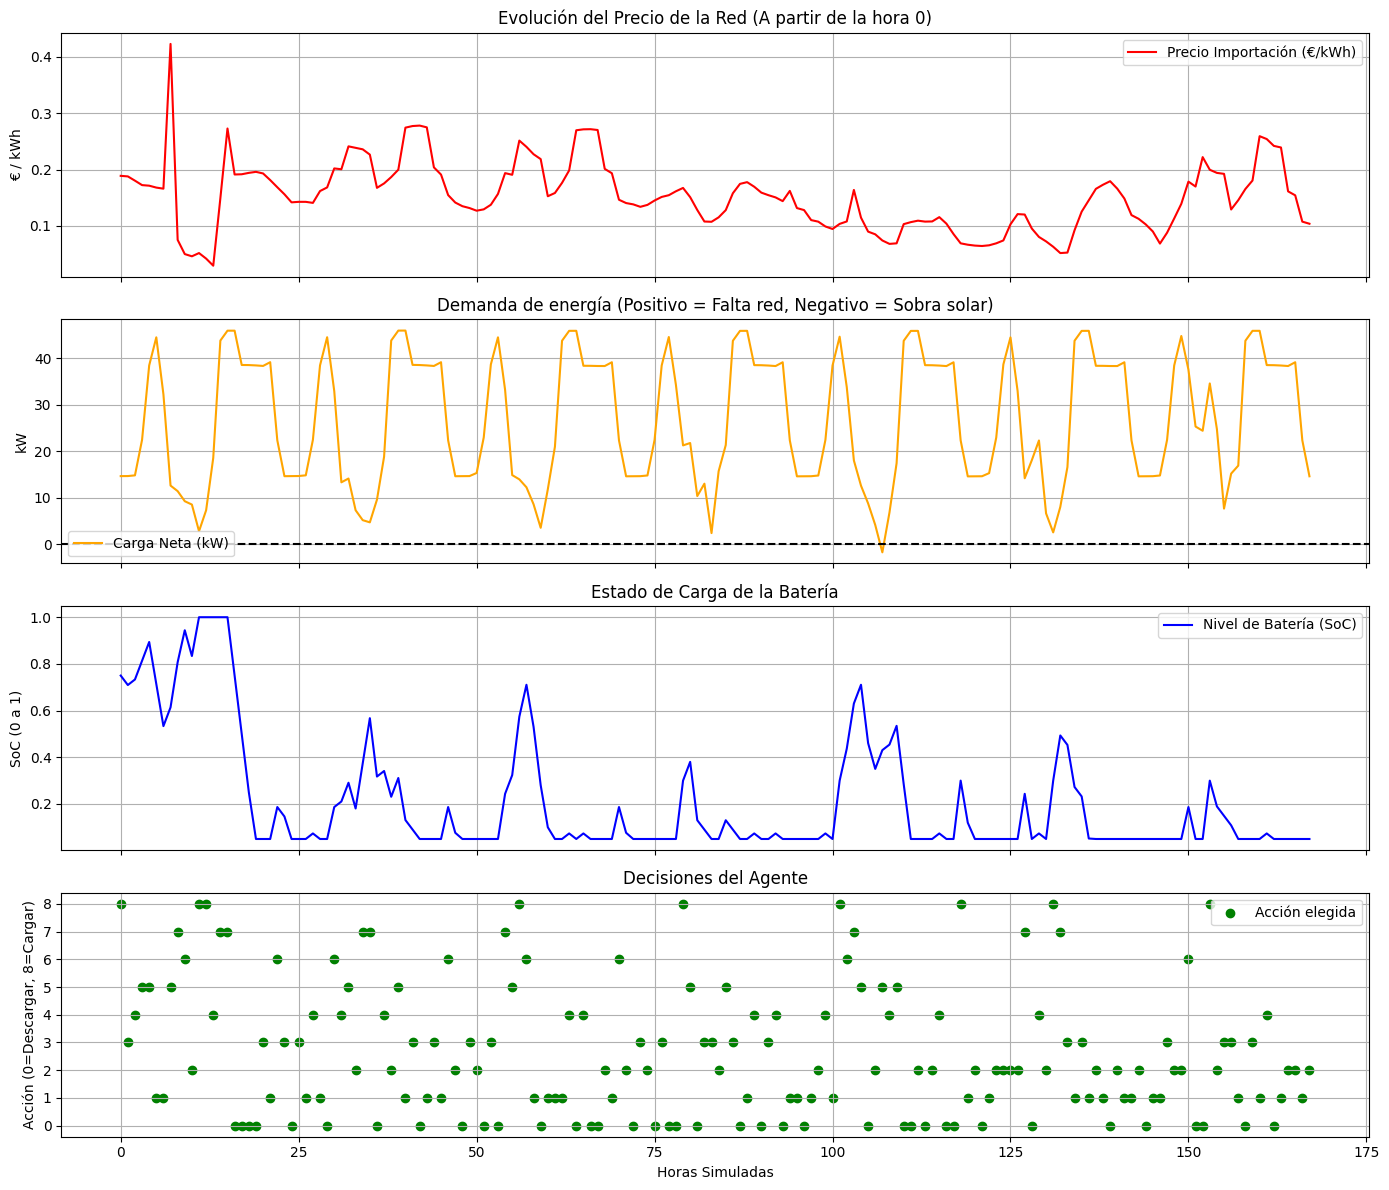

VERANO (Avanzando hasta Julio):
Avanzando simulación hasta la hora 4344 con el agente al mando...


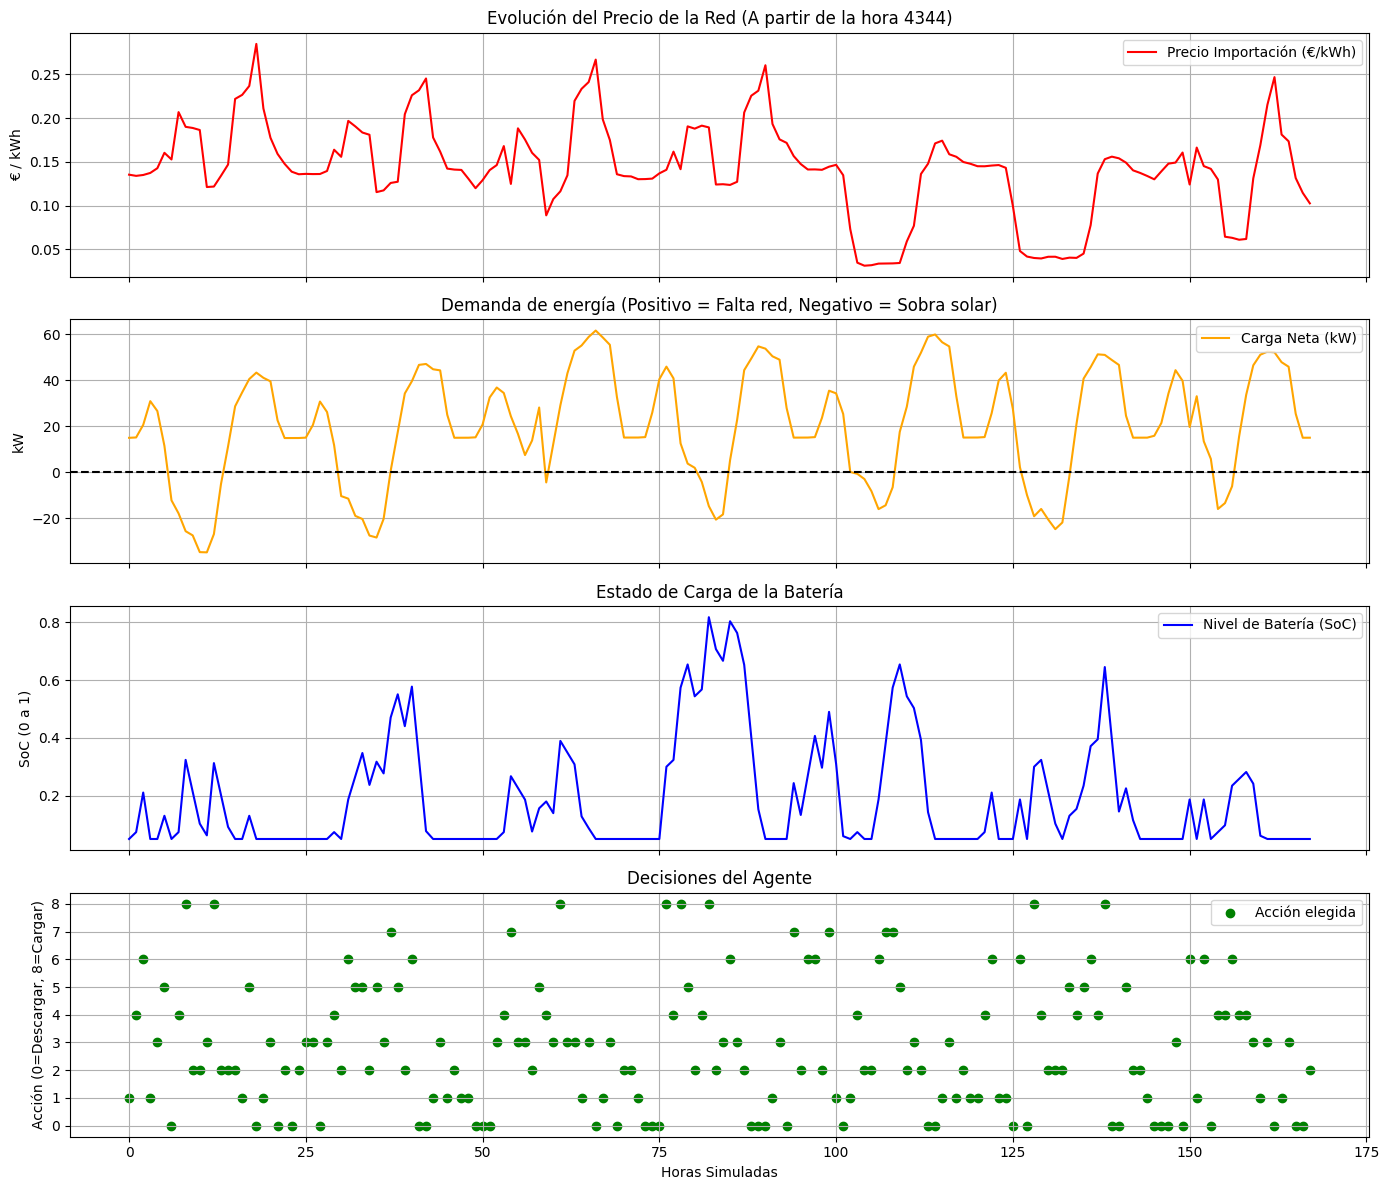

In [ ]:
# 1. Definir qué modelo queremos visualizar
ruta_modelo = GLOBAL_BEST_PATH

# 2. Cargar la Q-Table
print(f"Cargando modelo desde: {ruta_modelo}")
with open(ruta_modelo, 'rb') as f:
    q_table_cargada = pickle.load(f)

print(f"Q-Table cargada. Estados descubiertos: {len(q_table_cargada)}")

# 3. Lanzar visualizaciones
print("\n--- COMPORTAMIENTO TEMPORAL (1 SEMANA) ---")
print("INVIERNO (Arrancando el 1 de Enero):")
visualizar_comportamiento(eval_env, dict(q_table_cargada), dias=7, hora_inicio=0)

print("VERANO (Avanzando hasta Julio):")
# Nota: Ahora tardará unos segundos en calcular hasta la hora 4344 porque el agente va conduciendo
visualizar_comportamiento(eval_env, dict(q_table_cargada), dias=7, hora_inicio=4344)


MAPA GENERAL DE EXPLORACIÓN DE LA IA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



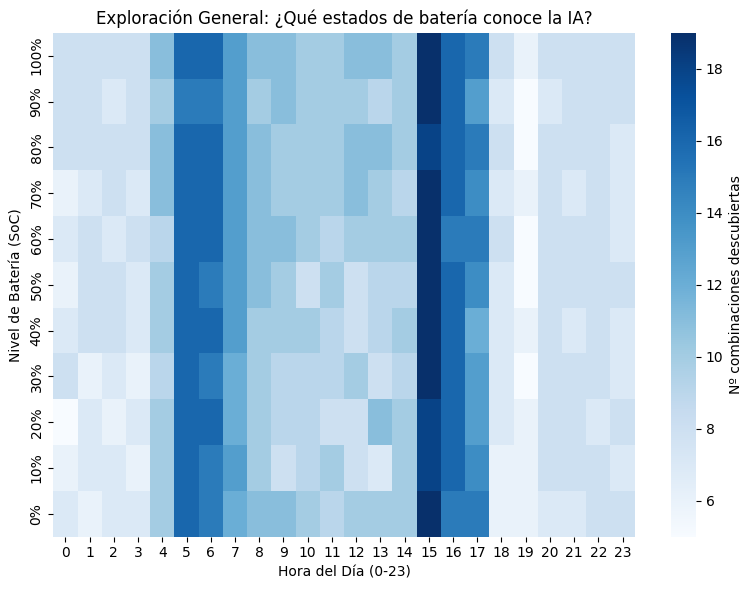


IMPACTO DEL PRECIO EN LA ESTRATEGIA
Fijamos la demanda en nivel medio (2) y variamos el precio del más barato (0) al más caro (3)

➤ Escenario: PRECIO = 0 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



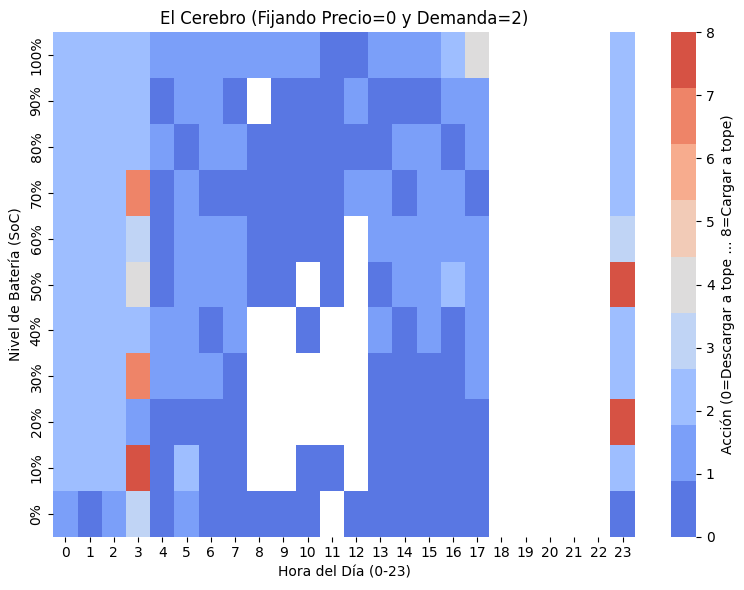


➤ Escenario: PRECIO = 1 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



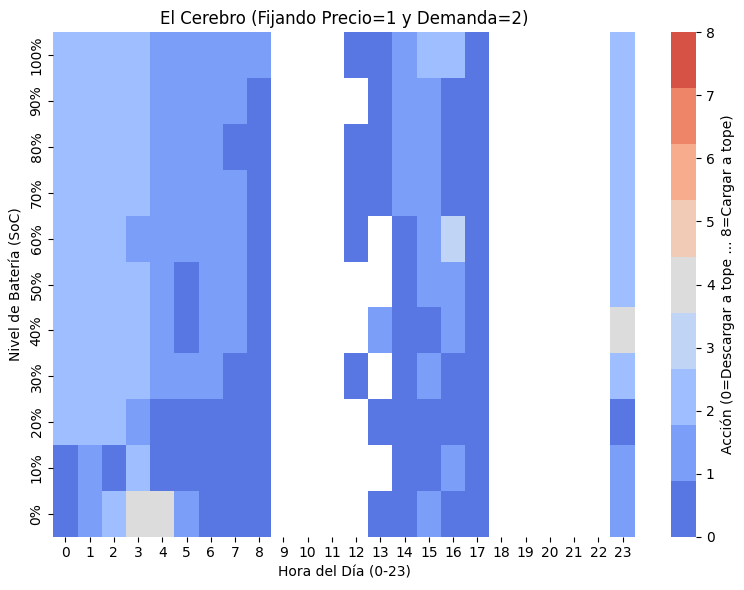


➤ Escenario: PRECIO = 2 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



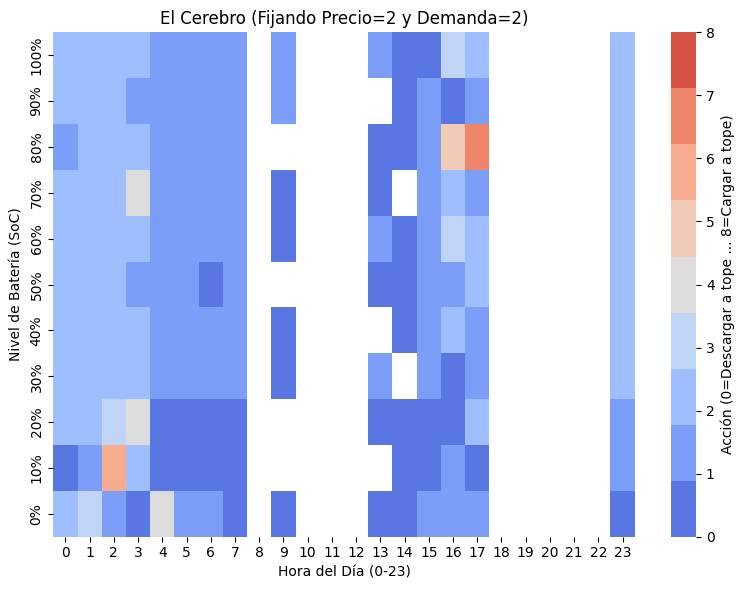


➤ Escenario: PRECIO = 3 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



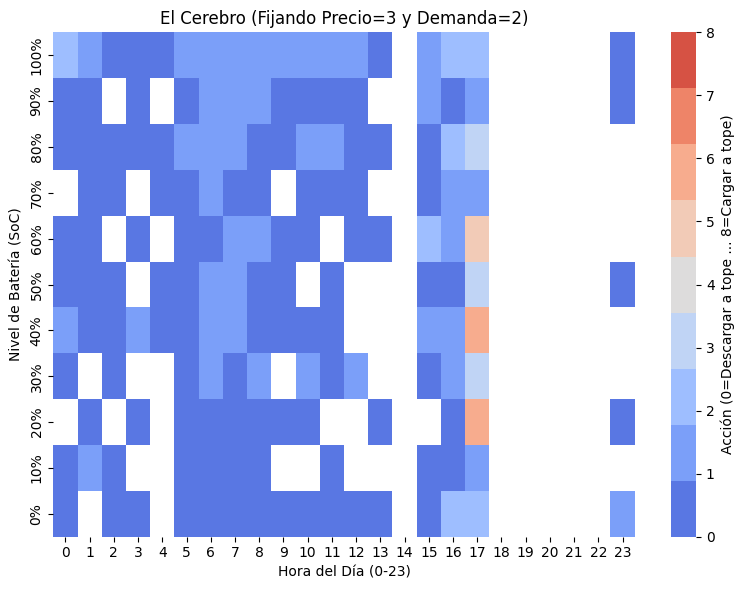


IMPACTO DE LA DEMANDA EN LA ESTRATEGIA
Fijamos el precio en nivel medio (2) y variamos la demanda de 'Mucha sobra solar' (0) a 'Falta mucha energía' (4)

➤ Escenario: PRECIO = 2 | DEMANDA = 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



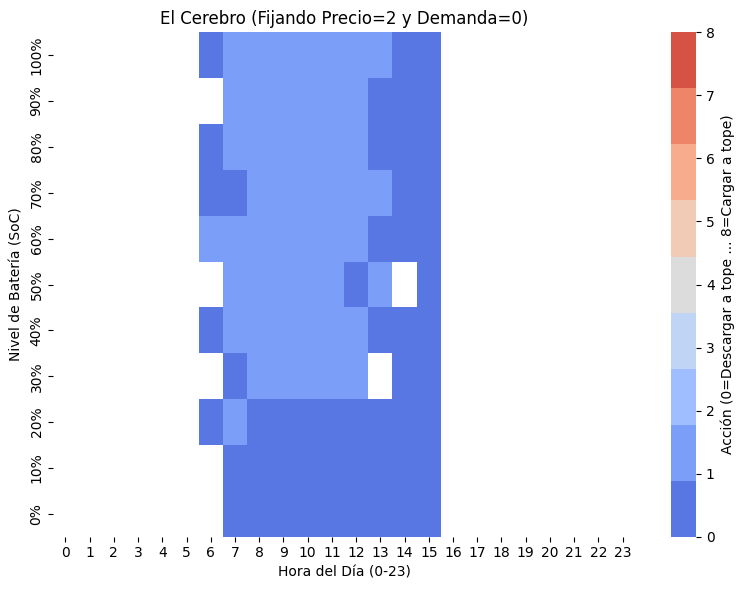


➤ Escenario: PRECIO = 2 | DEMANDA = 1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



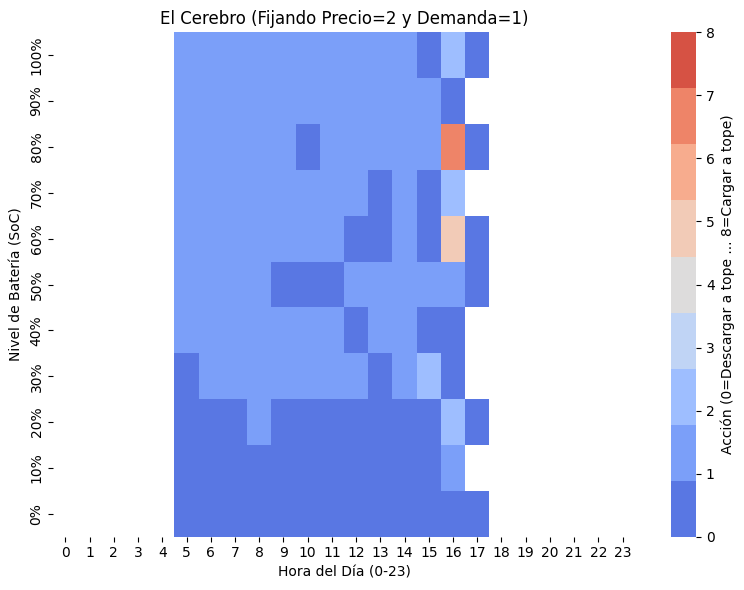


➤ Escenario: PRECIO = 2 | DEMANDA = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



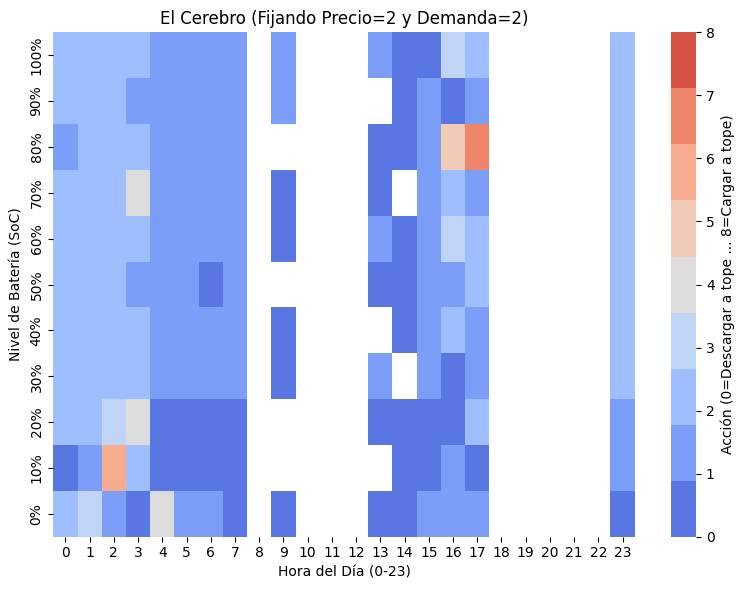


➤ Escenario: PRECIO = 2 | DEMANDA = 3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



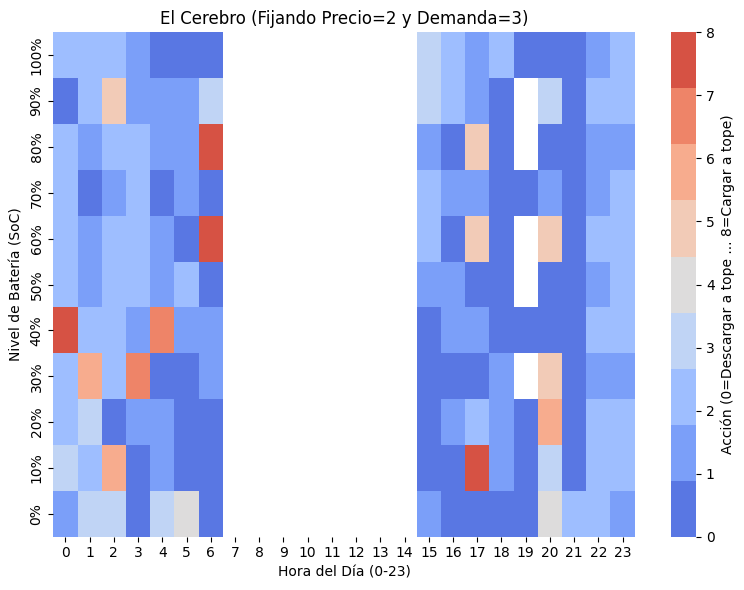


➤ Escenario: PRECIO = 2 | DEMANDA = 4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



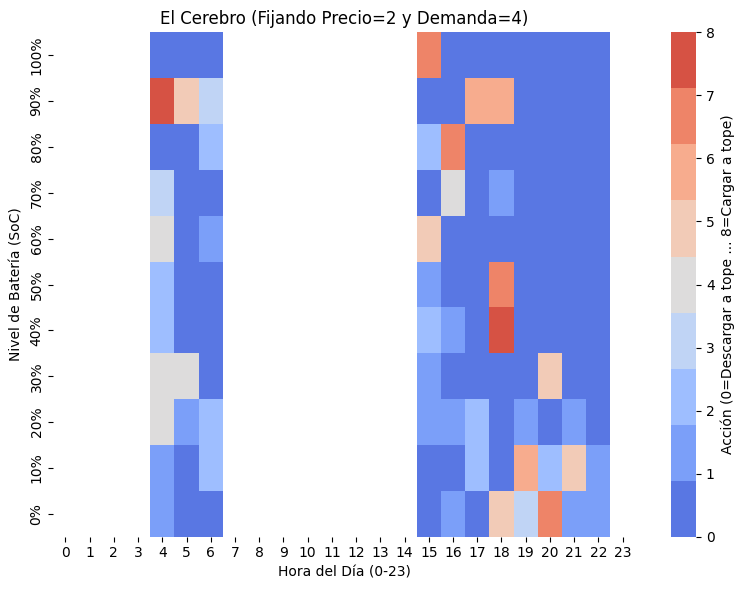

In [27]:
print("\n" + "="*50)
print("MAPA GENERAL DE EXPLORACIÓN DE LA IA")
print("="*50)
visualizar_exploracion(dict(q_table_cargada))


# IMPACTO DEL PRECIO EN BUCLE
print("\n" + "="*50)
print("IMPACTO DEL PRECIO EN LA ESTRATEGIA")
print("Fijamos la demanda en nivel medio (2) y variamos el precio del más barato (0) al más caro (3)")
print("="*50)

for precio in range(4):
    print(f"\n➤ Escenario: PRECIO = {precio} | Demanda = 2")
    visualizar_politica(dict(q_table_cargada), precio_fijo=precio, carga_fija=2)


# IMPACTO DE LA DEMANDA EN BUCLE
print("\n" + "="*50)
print("IMPACTO DE LA DEMANDA EN LA ESTRATEGIA")
print("Fijamos el precio en nivel medio (2) y variamos la demanda de 'Mucha sobra solar' (0) a 'Falta mucha energía' (4)")
print("="*50)

for demanda in range(5):
    print(f"\n➤ Escenario: PRECIO = 2 | DEMANDA = {demanda}")
    visualizar_politica(dict(q_table_cargada), precio_fijo=2, carga_fija=demanda)

### V3


---  COMPORTAMIENTO TEMPORAL (1 SEMANA) V3 ---
INVIERNO (Arrancando el 1 de Enero):


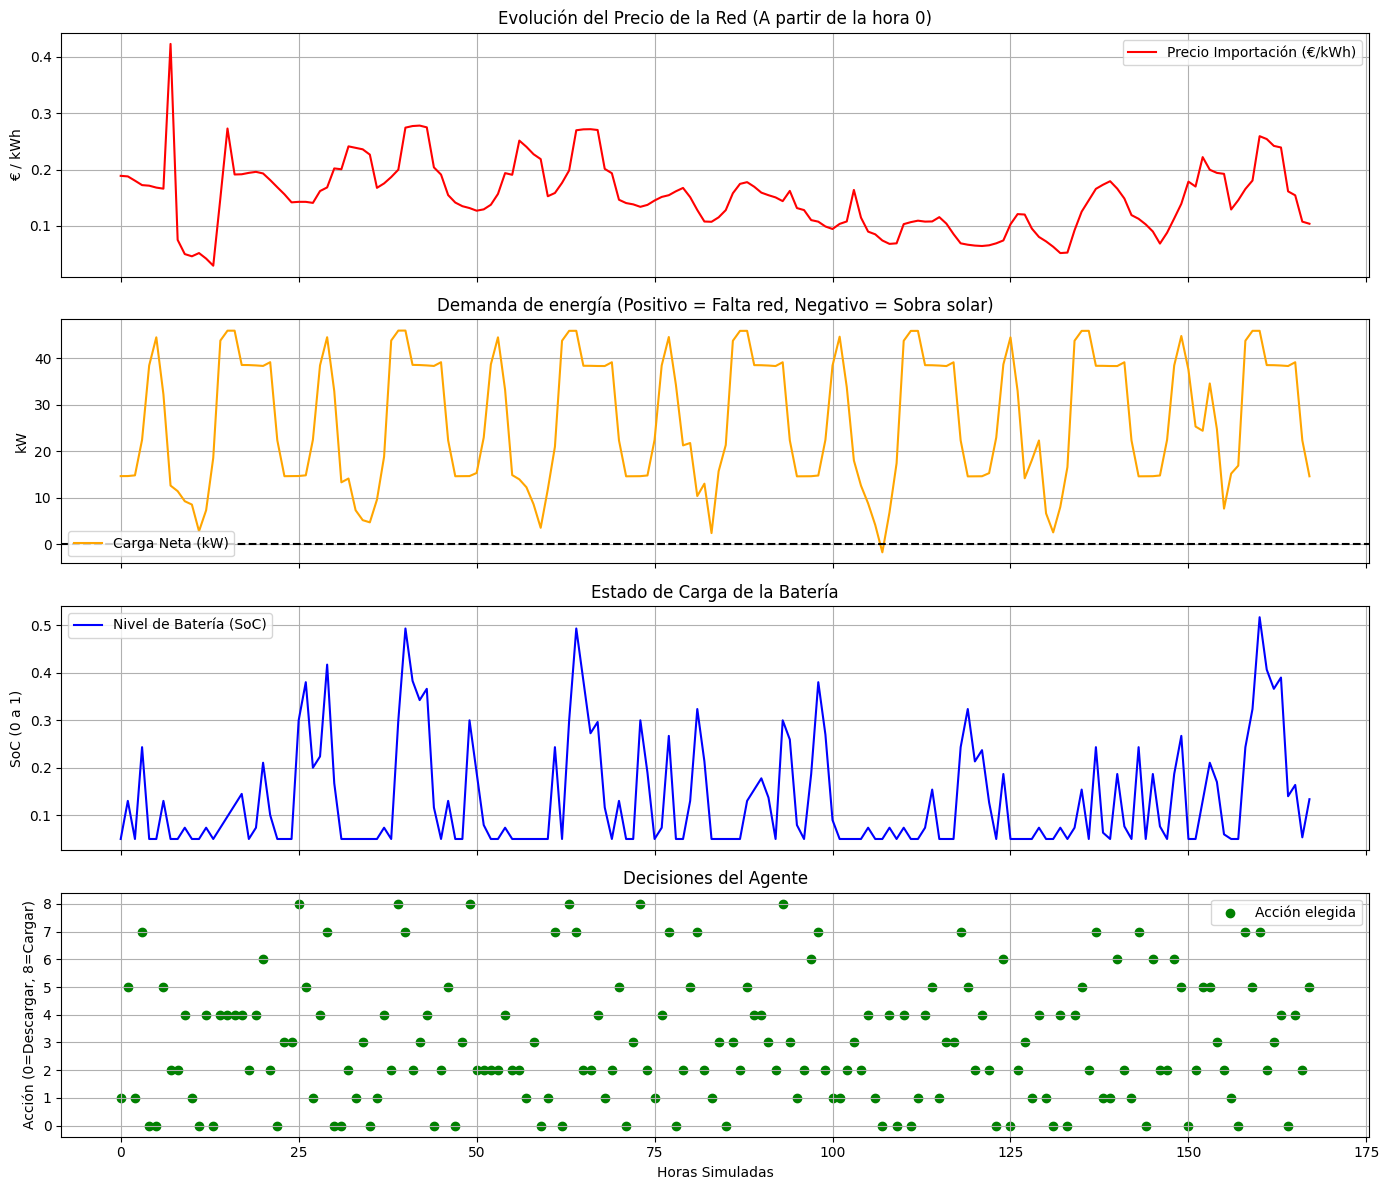

VERANO (Avanzando hasta Julio):
Avanzando simulación hasta la hora 4344 con el agente al mando...


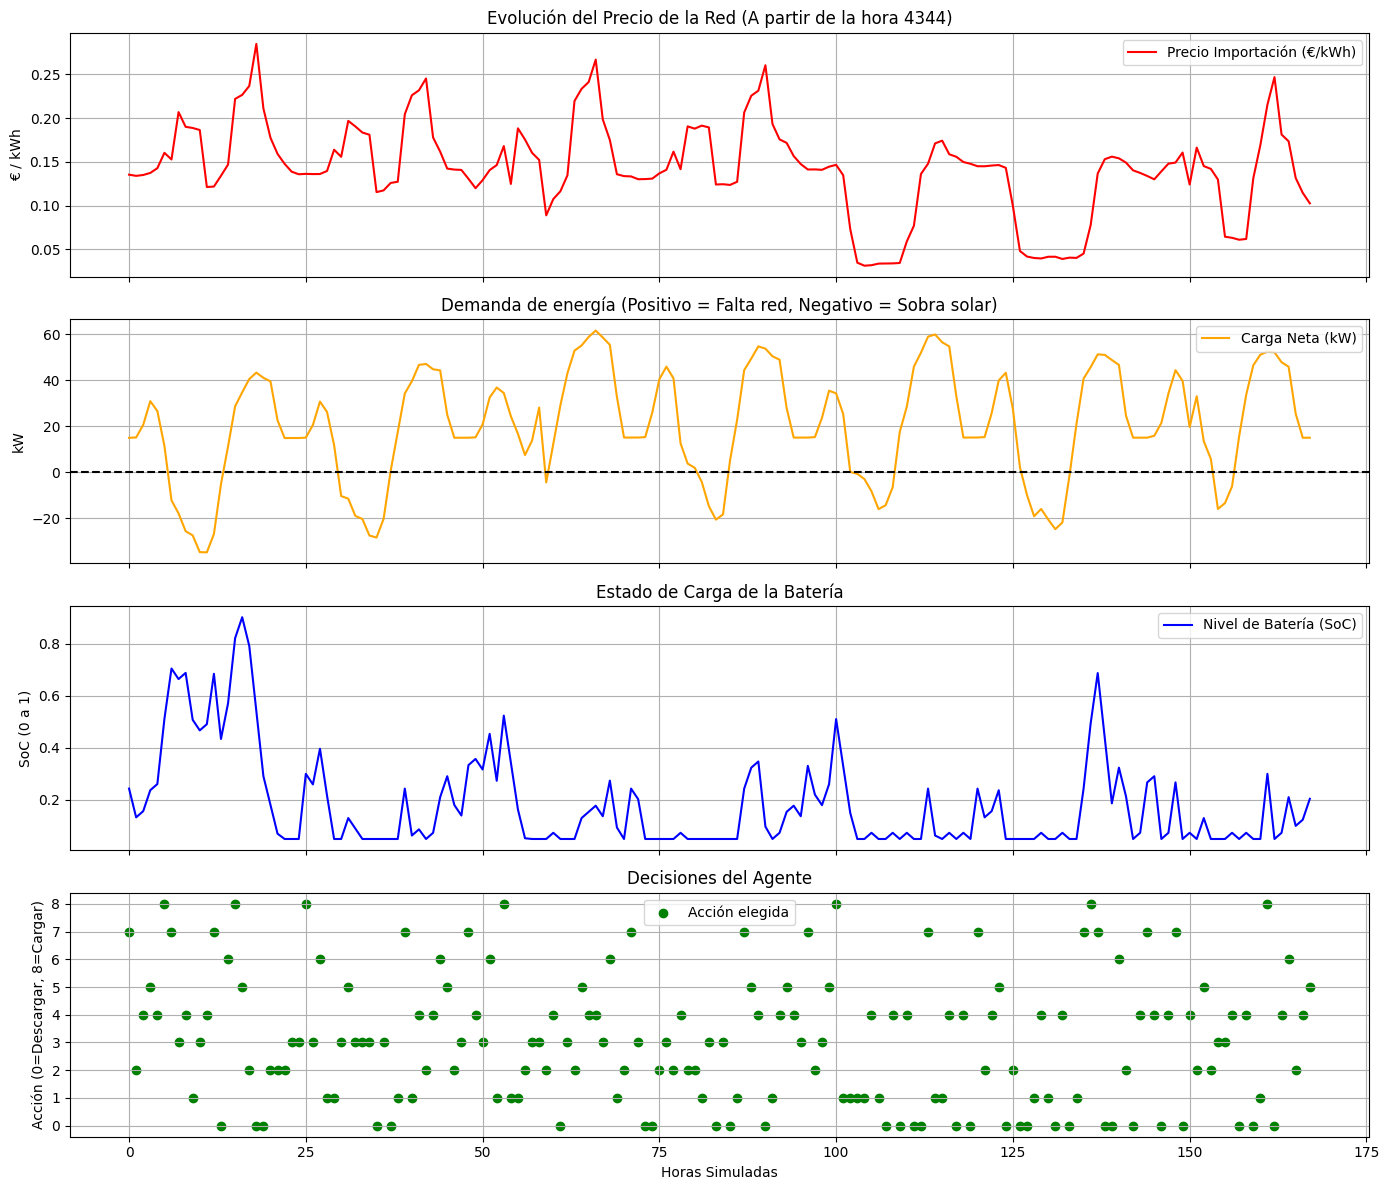

In [23]:
print("\n---  COMPORTAMIENTO TEMPORAL (1 SEMANA) V3 ---")
print("INVIERNO (Arrancando el 1 de Enero):")
visualizar_comportamiento(eval_env, dict(Q_v3), dias=7, hora_inicio=0)

print("VERANO (Avanzando hasta Julio):")
visualizar_comportamiento(eval_env, dict(Q_v3), dias=7, hora_inicio=4344)


MAPA GENERAL DE EXPLORACIÓN DE LA IA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



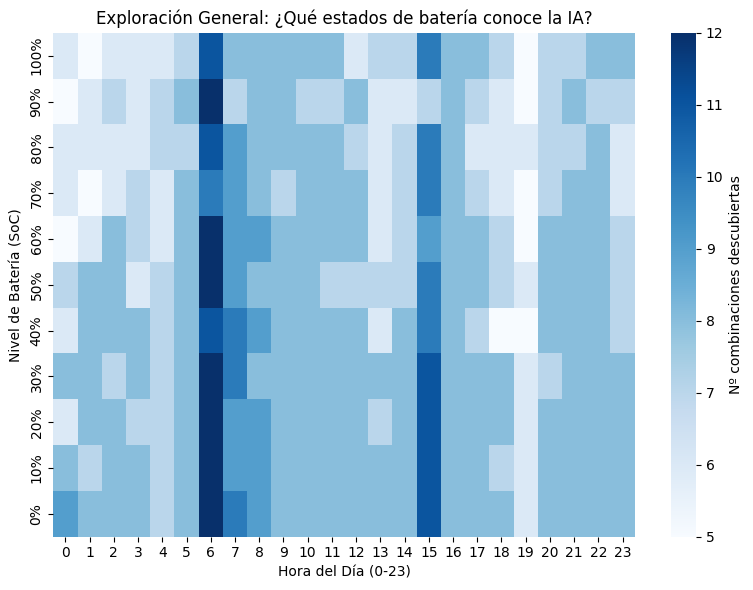


IMPACTO DEL PRECIO EN LA ESTRATEGIA
Fijamos la demanda en nivel medio (2) y variamos el precio del más barato (0) al más caro (3)

➤ Escenario: PRECIO = 0 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



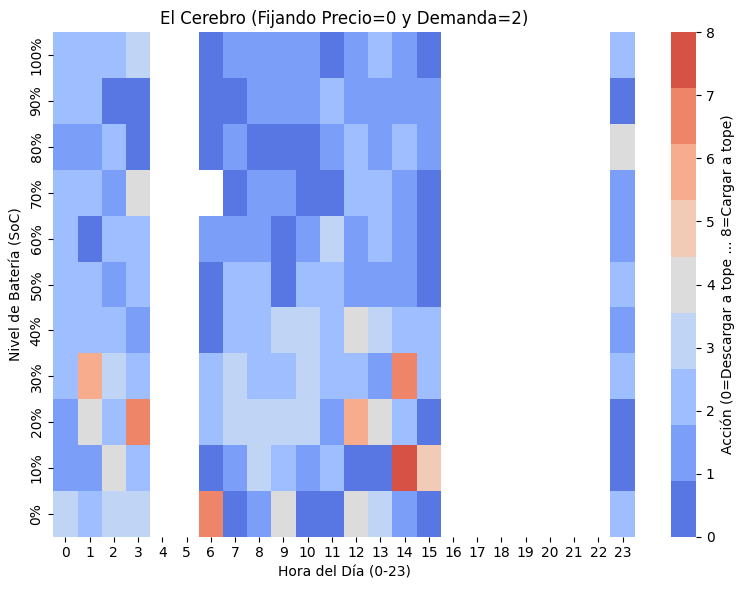


➤ Escenario: PRECIO = 1 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



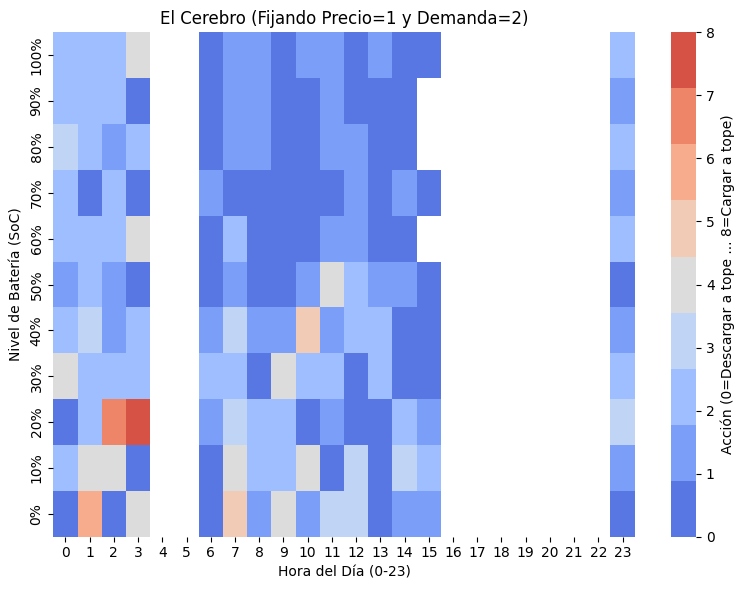


➤ Escenario: PRECIO = 2 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



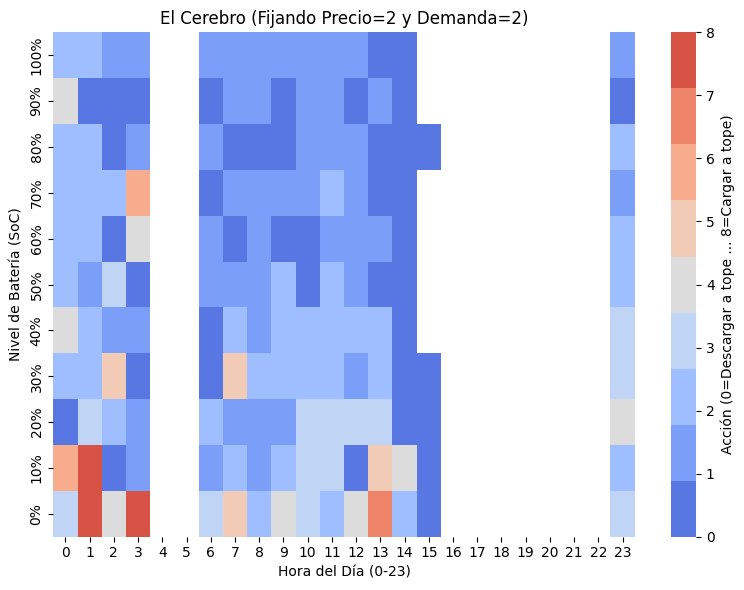


➤ Escenario: PRECIO = 3 | Demanda = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



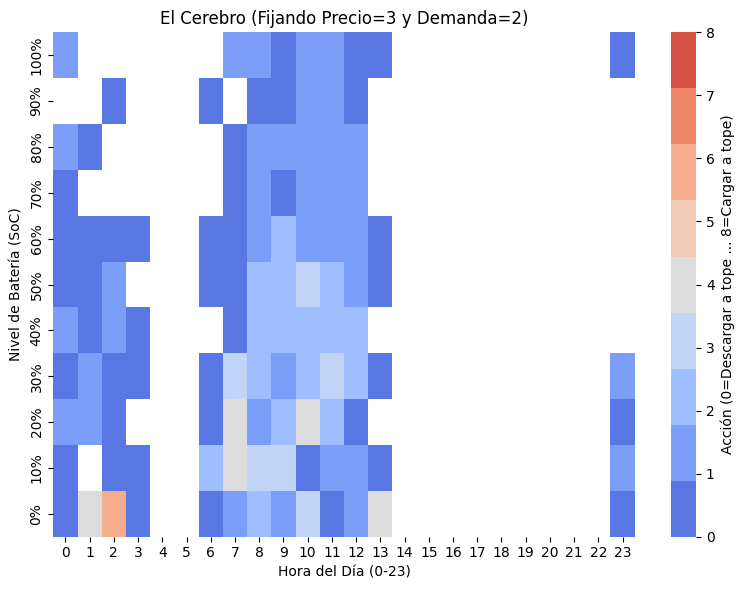


IMPACTO DE LA DEMANDA EN LA ESTRATEGIA
Fijamos el precio en nivel medio (2) y variamos la demanda de 'Mucha sobra solar' (0) a 'Falta mucha energía' (4)

➤ Escenario: PRECIO = 2 | DEMANDA = 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



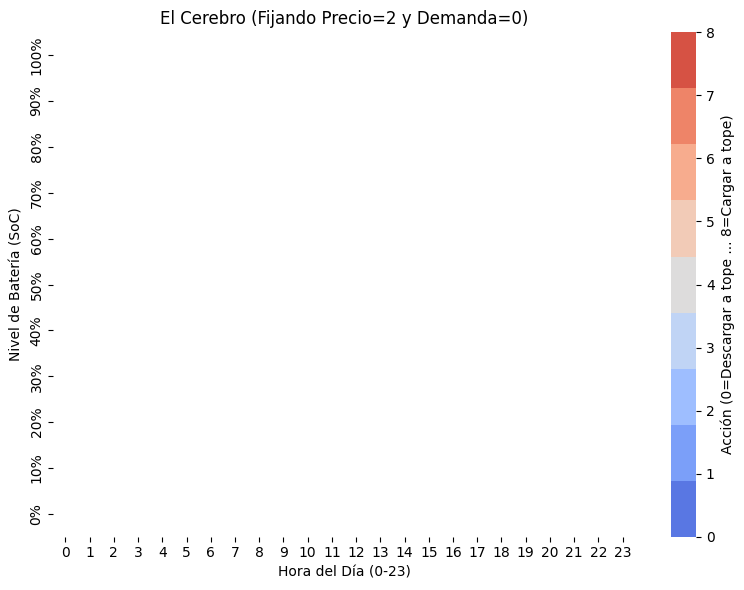


➤ Escenario: PRECIO = 2 | DEMANDA = 1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



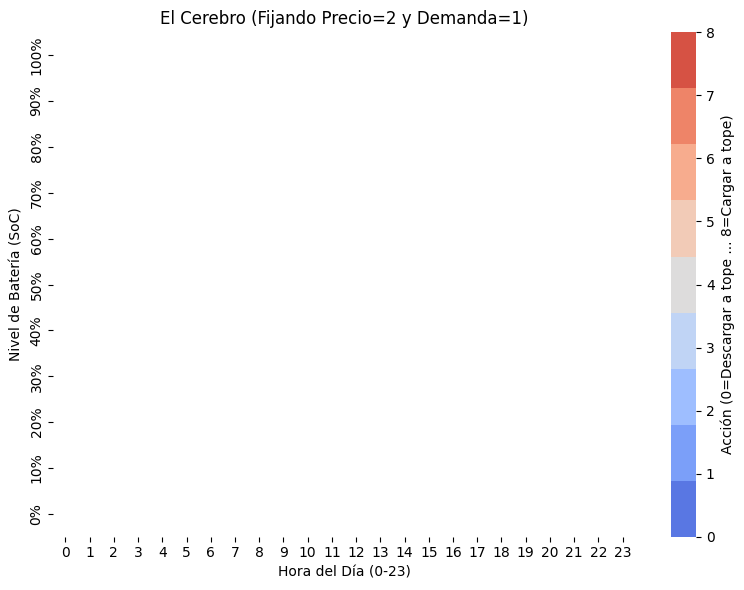


➤ Escenario: PRECIO = 2 | DEMANDA = 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



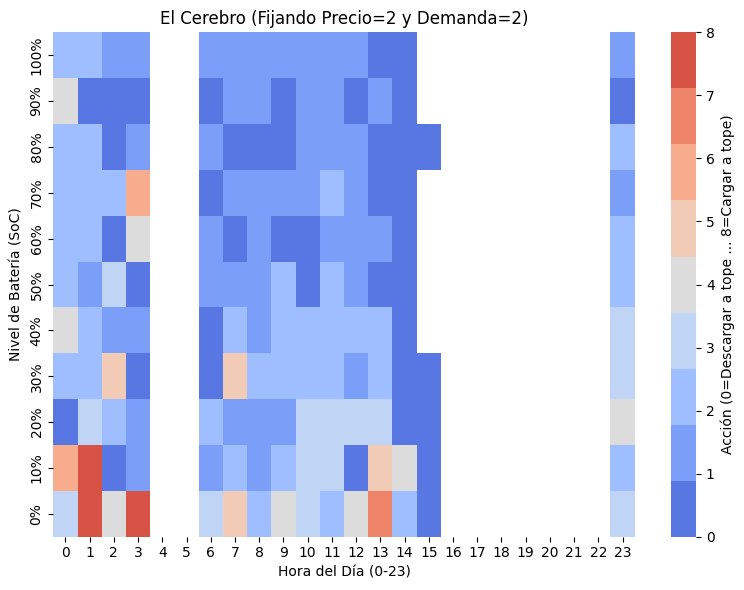


➤ Escenario: PRECIO = 2 | DEMANDA = 3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



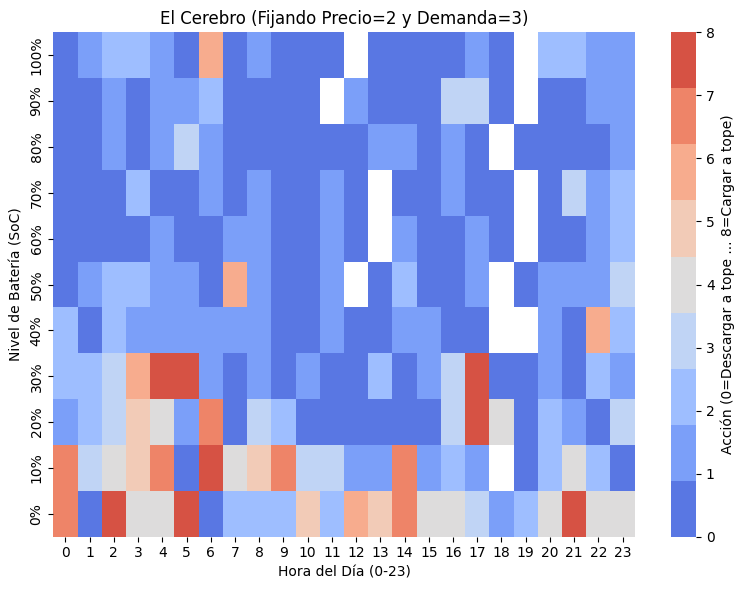


➤ Escenario: PRECIO = 2 | DEMANDA = 4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



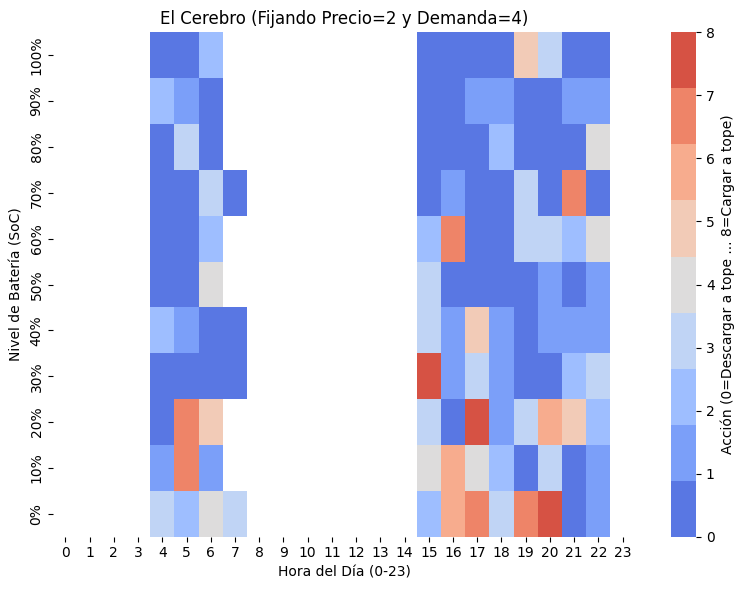

In [28]:
print("\n" + "="*50)
print("MAPA GENERAL DE EXPLORACIÓN DE LA IA")
print("="*50)
visualizar_exploracion(dict(Q_v3))


# IMPACTO DEL PRECIO EN BUCLE
print("\n" + "="*50)
print("IMPACTO DEL PRECIO EN LA ESTRATEGIA")
print("Fijamos la demanda en nivel medio (2) y variamos el precio del más barato (0) al más caro (3)")
print("="*50)

for precio in range(4):
    print(f"\n➤ Escenario: PRECIO = {precio} | Demanda = 2")
    visualizar_politica(dict(Q_v3), precio_fijo=precio, carga_fija=2)


# IMPACTO DE LA DEMANDA EN BUCLE
print("\n" + "="*50)
print("IMPACTO DE LA DEMANDA EN LA ESTRATEGIA")
print("Fijamos el precio en nivel medio (2) y variamos la demanda de 'Mucha sobra solar' (0) a 'Falta mucha energía' (4)")
print("="*50)

for demanda in range(5):
    print(f"\n➤ Escenario: PRECIO = 2 | DEMANDA = {demanda}")
    visualizar_politica(dict(Q_v3), precio_fijo=2, carga_fija=demanda)

# Entrenamiento